In [1]:
import os
import jax
jax.config.update("jax_enable_x64", True)

from jax import numpy as jnp
from jax import random

from jax import vjp, vmap
from tqdm import tqdm

key = random.PRNGKey(0)
key_init, key_cotangents = random.split(key,2)

from diffrax import diffeqsolve, ODETerm, Dopri5, SaveAt, PIDController
from diffrax import TqdmProgressMeter


import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
cb = sns.color_palette('colorblind')
cb_BuRd_map = LinearSegmentedColormap.from_list('cb_div', [cb[0], 'white', cb[3]])

import matplotlib.pyplot as plt
from cobras_extreme.plotting import set_defaults
colors = set_defaults()

# CoBRAS for FitzHugh-Nagumo Oscillator Networks
In this tutorial, we provide a brief (but comprehensive) tutorial for obtaining the CoBRAS modes for a fully-connected FitzHugh-Nagumo Oscillator network with $N=101$ nodes.

## FitzHugh-Nagumo Oscillator Networks (FHN)
We use the setup from Ansmann et al. [1]. We consider coupled FHN networks of $N$ units $(x_i, y_i)$ governed by


\begin{align} 
    \dot x_i & = x_i (a_i - x_i)(x_i - 1) - y_i + k \sum_j A_{ij}(x_j - x_i)\\  
    \dot y_i & = b_i x_i - c y_i
\end{align}

for $i = 1,2, \dots,  N$, where $A_{ij}$ is the adjacency matrix, $a_i, b_i$ and $c_i$ are internal parameters for each unit, and $k = 0.128/(N-1)$ is the coupling strength. For the fully-connected network, $A_{ij} = 1$ for all $i \neq j$. For simplicity, we choose $a_i=-0.02651$ and $c_i = 0.02$ to be constants for all nodes and $b_i = 0.006 + 0.008\frac{i-1}{N-1}$, which breaks the symmetry among all nodes. With these parameters, the system is chaotic and exhibits intermittent synchrony leading to extreme bursts of neuronal activity.  



## References
[1] Ansmann, Gerrit, et al. "Extreme events in excitable systems and mechanisms of their generation." Physical Review E—Statistical, Nonlinear, and Soft Matter Physics 88.5 (2013): 052911.

# Dynamics

In [2]:
def setup_FCN(N, k=0.128):
    '''Obtain the diffrax function for the FHN system with N nodes and coupling strength k.'''
    a = -0.02651
    c= 0.02 
    ns = jnp.arange(N)

    bs = 0.006 + ns/(N-1)*0.008 
    K =  k / (N-1)


    def f(z): 
        x = z[:N]
        y = z[N:]
        
        dx = x*(a-x)*(x-1) - y + K*(x.sum() - N*x)
        dy = bs*x - c*y
        return jnp.concatenate([dx, dy])

    def f_diffrax(t, y, args):
        return f(y)
    
    return f_diffrax

In [3]:
N = 101

# obtain dynamics
f_diffrax = setup_FCN(N=N)

# setup diffrax solver
solver = Dopri5()
term = ODETerm(f_diffrax)
tol = 1e-9

Tf = int(5e4)   # Total time to simulate
maxdt0 = 5e-1   # Maximum initial step size for the solver. This is not a hard limit, but it can help with convergence.
dt0 = 1e-1      

# adaptive stepsize controller for the solver
stepsize_controller = PIDController(rtol=tol, 
                                    atol=tol, 
                                    dtmax=maxdt0, 
                                    dtmin=1e-5
                                    )
base_max_steps = int(Tf/dt0)
max_steps = 10*base_max_steps

In [4]:
# create initial condition
x0_strength = 0.5
x0 = x0_strength * random.uniform(key_init, shape=(2*N,), 
                    minval=-1, maxval=1) 

# Save solution at each integer time step
saveat = SaveAt(ts=jnp.arange(0, Tf))

# create progress meter for the solver
progress_meter = TqdmProgressMeter(refresh_steps = 100)

# solve the system
# For this small network and large dt0, the system only 
# took about 90s to run on an NVIDIA GeForce RTX 2080Ti GPU. 
sol = diffeqsolve(term, solver, t0=0, t1=Tf, 
                  dt0=dt0, y0=x0, saveat=saveat, 
                  max_steps=max_steps, 
                  progress_meter=progress_meter
                  )



100.00%|██████████| [01:26<00:00,  1.16%/s]


In [5]:
# qoi at time t
def qoi_t(x):
    '''1/(2N) * sum_i (x_i^2 + y_i^2)'''
    return jnp.mean(x**2)

qoi_v = vmap(qoi_t, in_axes=(0,))

In [6]:
xs = sol.ys
ts = sol.ts
q = qoi_v(xs)

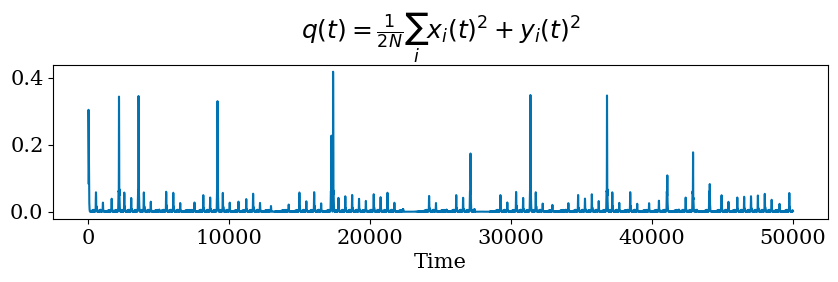

In [7]:


plt.figure(figsize=(10,2))
plt.plot(ts, q)
plt.xlabel('Time')

# Note: we take the mean of the squares over both x _and_ y, so we divide by 2N, not N.
plt.title(r'$q(t) = \frac{1}{2N}\sum_i x_i(t)^2 + y_i(t)^2$')
plt.show()

We can see above that we produce several extreme events over 50,000 time units. Because the system is chaotic, there's an initial transient where the sysetm collapses to chaotic attractor. We cut the first 5,000 steps here to make sure we're on the attractor.

In [8]:
n_remove = 5000
xs = xs[n_remove:]
q = q[n_remove:]

# Getting Gradients
To get gradients, we'll sample initial conditions x0 and differentiate our quantiy of interest over a short time horizon (here, $T=100$).

To efficiently sample the gradients, we'll first sample random cotangent vectors, $\xi$ and calculate $\nabla_{x} (\xi^T Q)(x_0)$

In [9]:
T_bwd = 100

save_dt = 1
saveat_bwd = SaveAt(ts=jnp.arange(0, T_bwd, save_dt))

def fwd_diffrax(x0):
    '''
    Diffrax solution for T_bwd time units starting from x0. This is used for the forward pass of the adjoint method.
    '''
    sol = diffeqsolve(term, solver, t0=0, t1=T_bwd, 
                  dt0=dt0, y0=x0, saveat=saveat_bwd, 
                  stepsize_controller=stepsize_controller, max_steps=max_steps)
    return sol.ys

def qoi_diffrax(x0):
    '''
    The forward evolution of the quanity of interest QoI starting from x0. 
    
    Q(x_0) = [q(t_1), q(t_2), ..., q(t_n)]
    '''
    return qoi_v(fwd_diffrax(x0))



In [10]:
def get_jvp(x0, cotangent):
    '''the jacobian vector product (jvp) samples gradients of the QoI'''
    y, vjp_fn = vjp(qoi_diffrax, x0)
    grad_sample = vjp_fn(cotangent)[0]
    return grad_sample

def get_jvp_lax(d):
    '''lax version in case there are memory issues.'''
    x0, cotangent = d
    return get_jvp(x0, cotangent)

get_jvp_v = vmap(get_jvp, in_axes=(0, 0))

In [11]:
# we break this up into batches to avoid memory issues. We'll collect 1/10th of the original set of samples. Because we use T=100, this captures sensitivities across the entire trajectory with significant overlap. In practice, you could use much less.

# for this small network and batch size, this took only about 3.5min on a NVIDIA GeForce RTX 2080Ti GPU. 

num_samples = len(xs)//10
output_dim = T_bwd
cotangets = random.normal(key_cotangents, shape=(num_samples, output_dim))
key = random.split(key)[0]

all_x0s = xs[::len(xs)//num_samples]

batch_size = 5
n_batches = num_samples // batch_size


print('Starting backwards solves...')
all_grad_data = []
for i in tqdm(range(n_batches)):
    cots = cotangets[i*batch_size:(i+1)*batch_size]
    x0s = all_x0s[i*batch_size:(i+1)*batch_size]
    x0s = x0s.to_device(jax.devices()[0]) # put on the correct device
    grad_data = get_jvp_v(x0s, cots)
    # grad_data = lax.map(get_jvp_lax, (x0s, cots))
    all_grad_data.append(grad_data)

Starting backwards solves...


100%|██████████| 900/900 [03:12<00:00,  4.68it/s]


In [12]:
all_grad_data = jnp.concatenate(all_grad_data, axis=0)

# Obtaining the Modes

To calculate the CoBRAS modes, we first take the SVD of the inner product matrix: 

$$
Y^T X = U \Sigma V^T
$$

And calculate the first $r-$ modes using the truncated SVD:

\begin{align}
\Phi &= X V_r \Sigma^{-1/2} \in \mathbb R^{m\times r}
    \\
\Psi &= Y U_r \Sigma^{-1/2} \in \mathbb R^{m\times r}

\end{align}

Where $X = \frac{1}{\sqrt{n_x}} [x_1, x_2, \dots x_{n_x}]$ and $Y = \frac{1}{\sqrt{n_g}} [g_1, g_2, \dots g_{n_g}]$

Note, the "method of snapshots" used for POD with large state dimensions is eactly the same when $ X = Y$. 

In [13]:
def balance_factorization(X,Y):
    '''
    Do the SVD
    '''
    cobras_balance = Y.T @ X

    U_cobras, S_cobras, Vh_cobras = jnp.linalg.svd(cobras_balance, 
                                                   full_matrices = False
                                                   )
    return U_cobras, S_cobras, Vh_cobras

def get_phi_psi(X, Y, U, S, Vh, r):
    '''Obtain the COBRAS modes Phi and Psi from the SVD factors U, S, Vh. 
    '''
    S_inv_sqrt_r = jnp.diag(1.0 / jnp.sqrt(S[:r]))
    U_r = U[:, :r]
    Vh_r = Vh[:r, :]
    
    Phi = X @ Vh_r.T @ S_inv_sqrt_r
    Psi = Y @ U_r @ S_inv_sqrt_r
    
    return Phi, Psi

def get_modes(x_real, g_real, r = 20): 
    n_grad = x_real.shape[0]
    n_snap = g_real.shape[0]
    Y_cobras = 1/jnp.sqrt(n_grad) * g_real.T
    X_cobras = 1/jnp.sqrt(n_snap) * x_real.T

    cobras_balance = Y_cobras.T @ X_cobras

    U_cobras, S_cobras, Vh_cobras = jnp.linalg.svd(cobras_balance, full_matrices = False)
    Phi_cobras, Psi_cobras = get_phi_psi(X_cobras, Y_cobras, U_cobras, S_cobras, Vh_cobras, r=r)
    
    return {'Phi': Phi_cobras, 'Psi': Psi_cobras, 'S': S_cobras}

For this example, $n_x$ is unnecesarily large, so we downsample significantly to peform the matrix calculations. 

In [14]:
n_downsample = 10
n_x = len(xs[::n_downsample])
n_g = len(all_grad_data)

X = jnp.sqrt(1/n_x) * xs[::n_downsample]
Y = jnp.sqrt(1/n_g) * all_grad_data

In [15]:
cobras_modes = get_modes(X, Y, r=20)
pod_modes = get_modes(X, X, r=20) 


In [16]:
# for POD, we could also subtract the mean from X before doing the SVD, 
# but in this case it doesn't make a significant difference. because 
# 0 is a fixed point of the system, and the mean is close to 0 anyway:
# The maximum mean value across all dimensions over the mean norm is
# just about 1%. Play around with subtracting though, if you like!
jnp.abs(X.mean(axis=0)).max() / (jnp.linalg.norm(X, axis=0).mean())

Array(0.01221873, dtype=float64)

Below we see that the CoBRAS SVD decays significantly faster than POD. Importantly, the dominant CoBRAS modes capture 99.9% of the remaining energy. We plot the dominant two $\Psi$ modes below for POD and CoBRAS. Importantly, CoBRAS captures the criticality of node #23!

In [17]:
def remaining_svd_energy(S): 
    return 1 - jnp.cumsum(S**2) / jnp.sum(S**2)

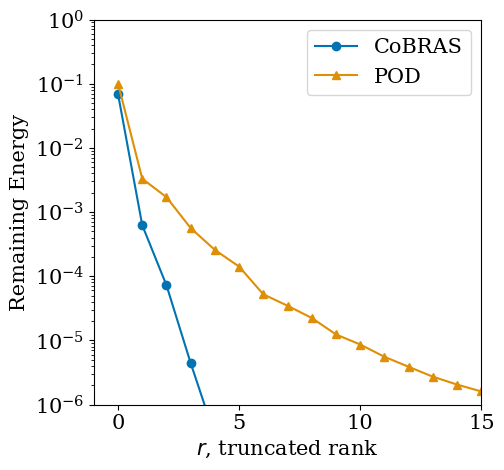

In [18]:
plt.figure(figsize=(5,5))
plt.plot(remaining_svd_energy(cobras_modes['S']), 'o-', label='CoBRAS',)
plt.plot(remaining_svd_energy(pod_modes['S']), '^-', label='POD')

plt.xlim(-1,15)
plt.ylim(1e-6,1)
plt.yscale('log')
plt.xlabel(r'$r$, truncated rank')
plt.ylabel('Remaining Energy')
plt.legend()
plt.show()

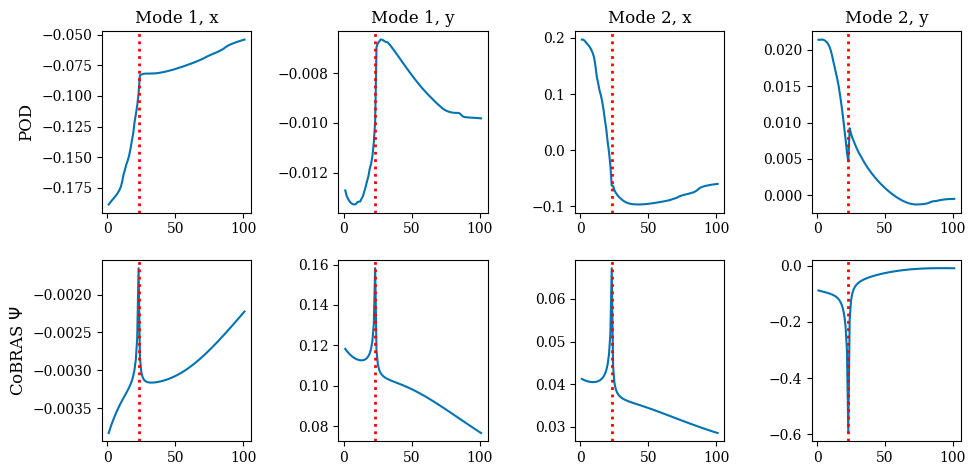

In [19]:
n_modes_plot = 2
fig, axes = plt.subplots(2,2*n_modes_plot, figsize=(10,5))

node_idxes = jnp.arange(1, N+1)

for mode_type_i, modes in enumerate([pod_modes['Psi'], cobras_modes['Psi']]):
    for mode_i in range(n_modes_plot):
        mode = modes[:, mode_i]
        mode /= jnp.linalg.norm(mode)
        for xy_i in range(2): 
            if xy_i == 0: 
                mode_xy = mode[:N]
            else: 
                mode_xy = mode[N:]
            ax = axes[mode_type_i, 2*mode_i + xy_i]
            ax.plot(node_idxes, mode_xy)
            ax.tick_params(labelsize=10)
            
            

for i_ax, ax in enumerate(axes[0,:]):
    if i_ax %2 ==0 :
        extra_str = 'x'
    else:
        extra_str = 'y'
    ax.set_title(f'Mode {i_ax//2 + 1}, {extra_str}', fontsize=12)
    
axes[0,0].set_ylabel('POD', fontsize=12)
axes[1,0].set_ylabel(r'CoBRAS $\Psi$', fontsize=12)
    
    
crit_idx = 23
for ax in axes.flatten():
    ax.axvline(x=crit_idx, color='red', linestyle=':', lw=2)

fig.tight_layout()


# Projected Coordinates
Below, we plot the system in the dominant POD and CoBRAS coordinates $z = \Psi^T x$. Clearly CoBRAS retains much cleaner structure, and the extreme events are formed by transients diverging off the boundary. 

In [20]:
z_cobras = xs @ cobras_modes['Psi']
z_pod = xs @ pod_modes['Psi']

In [21]:
def window_labels(q, q0, T):
    """
    q: 1D array of shape (N+1,)
    q0: threshold
    T: integer time horizon (inclusive)
    
    Returns:
        labels: 1D array of shape (N+1-T,)
                labels[t] = 1 if max(q[t : t+T+1]) >= q0
    """
    q = jnp.asarray(q)
    N = q.shape[0] - 1

    # Build sliding windows using stride tricks via jax.lax
    # We create a (N+1-T, T+1) matrix where each row is q[t:t+T+1]
    idx = jnp.arange(N + 1 - T)[:, None] + jnp.arange(T + 1)[None, :]
    windows = q[idx]  # shape (N+1-T, T+1)

    # Compute max over each window
    max_vals = jnp.max(windows, axis=1)
    # Compare to threshold
    labels = (max_vals >= q0).astype(jnp.int32)
    return labels


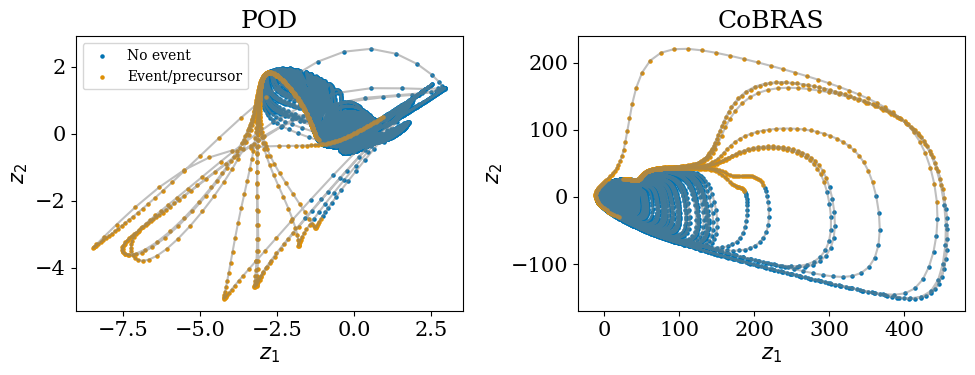

In [22]:
q_thresh = q.mean() + 4 * q.std()

t_pred = 50
labels = window_labels(q, q0=q.mean() + 4*q.std(), T=t_pred)

labels_idx = labels == 1

fig, axes = plt.subplots(1,2, figsize=(10,4))

for i, z in enumerate([z_pod, z_cobras]):
    
    axes[i].plot(z[:,0], z[:,1], alpha=0.5, c = 'gray')
    axes[i].scatter(z[:-t_pred][~labels_idx,0], z[:-t_pred][~labels_idx,1], s = 5, 
                    label = r'No event')
    axes[i].scatter(z[:-t_pred][labels_idx,0], z[:-t_pred][labels_idx,1], s =5, 
                    label = r'Event/precursor')
    axes[i].set_xlabel(r'$z_1$')
    axes[i].set_ylabel(r'$z_2$')
    


axes[0].legend(fontsize=10, loc = 'upper left')
axes[0].set_title('POD')
axes[1].set_title('CoBRAS')
fig.tight_layout()
plt.show()

# Classification

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

n_train = int(0.8 * len(labels))
train_idx = jnp.arange(n_train)
test_idx = jnp.arange(n_train, len(labels))

z = z_cobras[:, :2]

# We use a standard scaler to put everything on the same scale
scaler = StandardScaler()
z_train = scaler.fit_transform(z[train_idx])
z_test = scaler.transform(z[test_idx])

svm_kwargs = dict(kernel='rbf',
                    C=1.0, 
                    gamma='scale', # chosen based on features and variance
                    class_weight = 'balanced', # because we have an imbalance between the two classes
                    random_state = 0,
                    max_iter=50000,
                    probability=False
                    )

labels_train = labels[train_idx]
labels_test = labels[test_idx]
svm = SVC(**svm_kwargs)
svm.fit(z_train, labels_train)

preds = svm.predict(scaler.transform(z))

cm = confusion_matrix(labels_test, 
                        preds[test_idx], 
                        normalize = 'true')
tn = cm[0,0]
tp = cm[1,1]
fp = cm[0,1]
fn = cm[1,0]

print(f'TN: {tn:.2f}, TP: {tp:.2f}')

TN: 0.97, TP: 0.92


We can jaxify these RBFs by extracting the support vectors, dual coefficients, scale factor, etc. That way we can easily calculate the gradient of the decision boundary. 

In [24]:
def get_svm_fns(svm, scaler):
    # Extract static parameters once
    sv = jnp.array(svm.support_vectors_)    # (n_sv, n_features)
    dual_coefs = jnp.array(svm.dual_coef_.ravel())  # (n_sv,)
    gamma = svm._gamma
    b = jnp.array(svm.intercept_)
    s_mean = jnp.array(scaler.mean_)
    s_scale = jnp.array(scaler.scale_)

    @jax.jit
    def decision_function(x_unscaled):
        """x: (n_points, n_features)"""
        x = (x_unscaled - s_mean) / s_scale
        sv_sqnorms = jnp.sum(sv ** 2, axis=1)
        x_sqnorms  = jnp.sum(x ** 2, axis=1)
        sq_dists = x_sqnorms[:, None] + sv_sqnorms[None, :] - 2 * (x @ sv.T)
        K = jnp.exp(-gamma * sq_dists)
        return (K * dual_coefs[None, :]).sum(axis=1) + b


    @jax.jit
    def svm_gradient(x_unscaled):
        """x: (n_points, n_features)"""
        x = (x_unscaled - s_mean) / s_scale
        sv_sqnorms = jnp.sum(sv ** 2, axis=1)
        x_sqnorms  = jnp.sum(x ** 2, axis=1)
        sq_dists = x_sqnorms[:, None] + sv_sqnorms[None, :] - 2 * (x @ sv.T)
        K = jnp.exp(-gamma * sq_dists)
        W = K * dual_coefs[None, :]
        scaled_grad = 2 * gamma * (W @ sv - W.sum(axis=1, keepdims=True) * x)
        
        # unscale it
        return scaled_grad / s_scale
    return decision_function, svm_gradient

decision_function, svm_gradient = get_svm_fns(svm, scaler) 

In [25]:
res = 500

# CoBRAS units
xx, yy = jnp.meshgrid(
    jnp.linspace(z_cobras[:, 0].min()-50, z_cobras[:,  0].max(), res),
    jnp.linspace(z_cobras[:, 1].min()*1.1, z_cobras[:, 1].max(), res)
)

# scale the grid points before feeding into the svm, because the svm was trained on scaled data
grid_scaled = scaler.transform(jnp.c_[xx.ravel(), yy.ravel()])
zz = svm.decision_function(grid_scaled).reshape(xx.shape)

s_plot = 3

cbound = 3
cbounds = {'vmin': -cbound,
           'vmax': cbound}

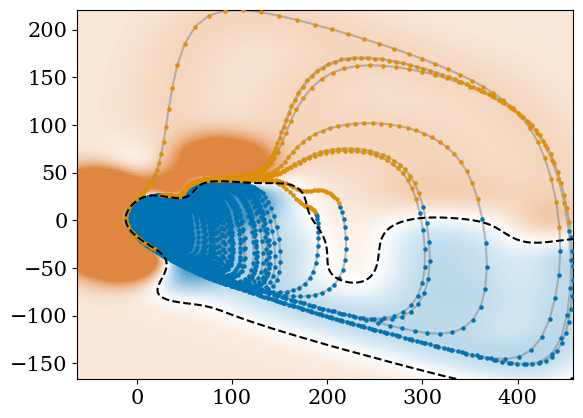

In [26]:
plt.pcolormesh(xx, yy, zz,  cmap =  cb_BuRd_map, alpha = 0.75, **cbounds, zorder = 1)
plt.plot(z_cobras[:,0], z_cobras[:,1], alpha=0.5, c = 'gray', zorder = 2)
plt.scatter(z_cobras[:-t_pred][~labels_idx,0], 
            z_cobras[:-t_pred][~labels_idx,1], 
            s = 5, 
            label = r'No event', zorder = 3)
plt.scatter(z_cobras[:-t_pred][labels_idx,0], 
            z_cobras[:-t_pred][labels_idx,1], 
            s =5, 
            label = r'Event/precursor', zorder = 4)
plt.contour(xx, yy, zz, levels=[0], colors='k', linestyles = '--', zorder=5)


# Controlling the System
We can use the decision boundary to control the system. We'll only activate the control when the SVM predicts that there will be an event within $t_pred = 50$ time units; that way the control is only active.

In this example, we just using a single starting point near an extreme event, but you should play around with others!

In [27]:
from jax import jit
from diffrax import diffeqsolve, ODETerm, Dopri5, SaveAt, PIDController


dt_control = 1 # actuation frequency
saveat_control = SaveAt(t0=True, t1=True)

solver = Dopri5()
term = ODETerm(f_diffrax)
tol = 1e-9

Tf = int(1e5)
maxdt0 = 5e-1
dt0 = 1e-2

# note, this is for the adapative stepsize, not the actual control
stepsize_controller = PIDController(rtol=tol, atol=tol, dtmax=maxdt0, dtmin=1e-5)


def control_step(t,y,args): 
    u = args[0]
    dydt = f_diffrax(t,y,0) + u
    return dydt
control_term = ODETerm(control_step)

@jit
def fwd_control(x0, u):
    dt0= 1e-2
    max_steps = 10*int(dt_control/dt0)
    sol = diffeqsolve(control_term, solver, t0=0, t1=dt_control, 
                  dt0=dt0, y0=x0, args=(u,),
                  saveat=saveat_control, 
                  stepsize_controller=stepsize_controller, max_steps=max_steps, 
                  )
    return sol.ys



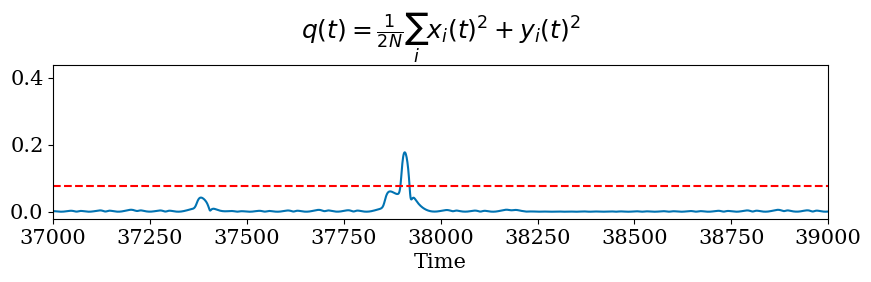

In [28]:

plt.figure(figsize=(10,2))
plt.plot(q)
plt.axhline(q_thresh, color='red', linestyle='--', label='Threshold')
plt.xlabel('Time')

# Note: we take the mean of the squares over both x _and_ y, so we divide by 2N, not N.
plt.title(r'$q(t) = \frac{1}{2N}\sum_i x_i(t)^2 + y_i(t)^2$')
plt.xlim(37000,39000)
plt.show()

In [29]:
Psi = cobras_modes['Psi']
Phi = cobras_modes['Phi']

n_ctrl_steps = int(1e3)

ctrl_strength =  0.01 * jnp.linalg.norm(xs, axis=1).mean()
print(ctrl_strength)
control_cutoff = n_ctrl_steps
truncate = 2
t0 = 37750

us = []
new_xs = []
for i in tqdm(range(n_ctrl_steps)):
    u = jnp.zeros_like(xs[0])
    if i == 0:
        x_curr = xs[t0]
    if i < control_cutoff:
        z_proj = (Psi[:,:truncate].T @ x_curr).T
        
        # compute SVM gradient
        svm_grad = svm_gradient(z_proj.reshape(1,-1)).reshape(-1)
        
        # normalize SVD grad to get ctrl direction
        unit_svm_grad = svm_grad / jnp.linalg.norm(svm_grad, axis=-1, keepdims=True)
        
        # use SVM to predict if there will be an event within t_pred time units
        dec = decision_function(z_proj.reshape(1,-1)) >= 0
        
        # latent control direction
        u_z = dec * unit_svm_grad
        
        # physical control direction
        u =  Phi[:,:truncate] @ u_z
        
        # we normalize the physical units to have a consistent control strength
        u_norm = jnp.linalg.norm(u)
        if u_norm !=0:
            u /= u_norm
            u *= -1 * ctrl_strength
        else:
            u = jnp.zeros_like(u)
    
    # integrate the system with zero-hold control
    x_next = fwd_control(x_curr, u)
    x_curr = x_next[-1]
    us.append(u)
    new_xs.append(x_curr)

us = jnp.array(us) 
new_xs = jnp.array(new_xs)
z_cobras_ctrl = new_xs @ cobras_modes['Psi']

0.007162585500305741


100%|██████████| 1000/1000 [00:16<00:00, 61.30it/s]


/tmp/ipykernel_4037359/4154337185.py:13: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, zz, label = 'SVM boundary',


Text(0, 0.5, 'CoBRAS controlled, t=220')

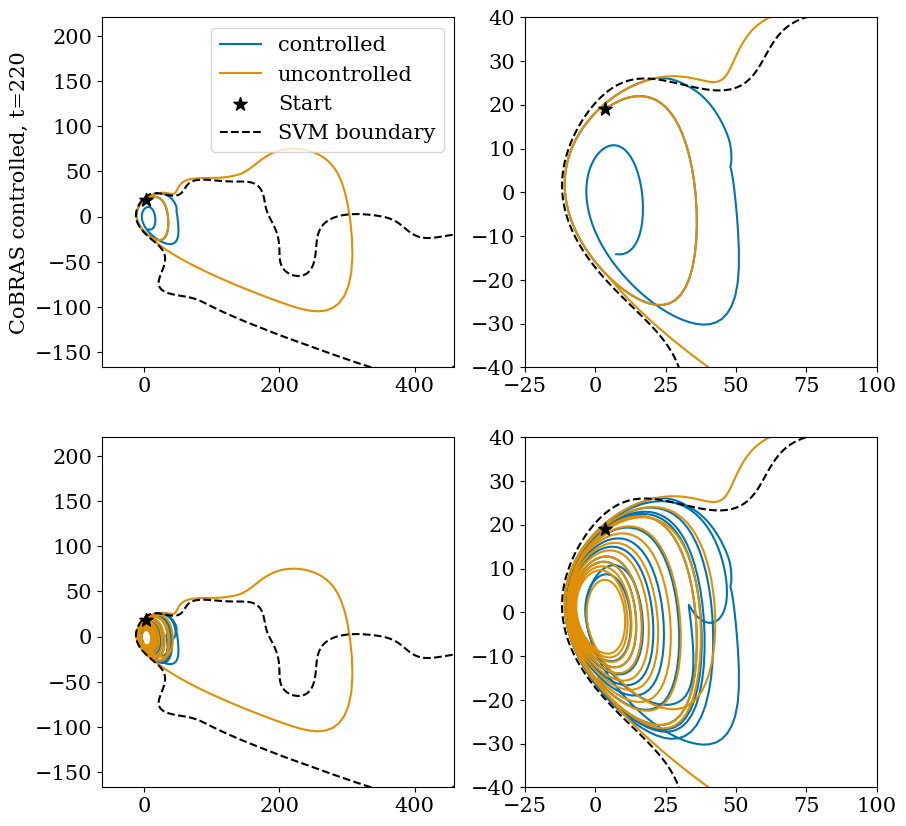

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

for i, t_plot in enumerate([220,1000]):
    for ax in axes[i]:
        ax.plot(z_cobras_ctrl[:t_plot,0], 
                z_cobras_ctrl[:t_plot,1],
                label = 'controlled'
                )
        ax.plot(z_cobras[t0:t0+n_ctrl_steps,0][:t_plot], 
                z_cobras[t0:t0+n_ctrl_steps,1][:t_plot], 
                label = 'uncontrolled'
                )
        ax.contour(xx, yy, zz, label = 'SVM boundary', 
                   levels=[0], colors='k', linestyles = '--')
        
        ax.scatter(z_cobras_ctrl[:1,0], z_cobras_ctrl[:1,1],
                   s=100, marker = '*', zorder = 10, c = 'k', label = 'Start')

    axes[i,1].set_xlim(-25,100)
    axes[i,1].set_ylim(-40,40)

from matplotlib.lines import Line2D
handles, labels = axes[0,0].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='k', linestyle='--'))
labels.append('SVM boundary')
axes[0,0].legend(handles, labels)


axes[0,0].set_ylabel('CoBRAS controlled, t=220')

plt.show()

As designed, we also see that the control is very sparse! Only activating once during the entire trajectory when it cross the boundary. 

Text(0.5, 0, 'Time')

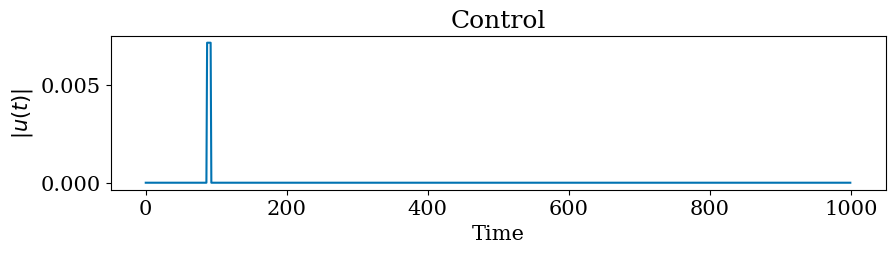

In [31]:
plt.figure(figsize=(10,2))
plt.title('Control')
plt.plot(jnp.linalg.norm(us, axis=1))
plt.ylabel(r'$|u(t)|$')
plt.xlabel('Time')